In [104]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import re

# Load Dataset

In [105]:
outreach = pd.read_excel("data/OutreachData.xlsx")
applicant = pd.read_excel("data/ApplicantData.xlsx")
campaign = pd.read_excel("data/CampaignData.xlsx")

print("Outreach Shape:", outreach.shape)
print("Applicant Shape:", applicant.shape)
print("Campaign Shape:", campaign.shape)

Outreach Shape: (37881, 8)
Applicant Shape: (37882, 4)
Campaign Shape: (23, 7)


# Initial Data Inspection

In [106]:
print("\nOutreach Info:")
print(outreach.info())

print("\nMissing Values:")
print(outreach.isnull().sum())


Outreach Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37881 entries, 0 to 37880
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Reference_ID         37881 non-null  object
 1   Received_At          37881 non-null  object
 2   University           37881 non-null  object
 3   Caller_Name          37881 non-null  object
 4   Outcome_1            37881 non-null  object
 5   Remark               4077 non-null   object
 6   Campaign_ID          37881 non-null  object
 7   Escalation_Required  37881 non-null  object
dtypes: object(8)
memory usage: 2.3+ MB
None

Missing Values:
Reference_ID               0
Received_At                0
University                 0
Caller_Name                0
Outcome_1                  0
Remark                 33804
Campaign_ID                0
Escalation_Required        0
dtype: int64


In [107]:
outreach.head()

,Reference_ID,Received_At,University,Caller_Name,Outcome_1,Remark,Campaign_ID,Escalation_Required
0,12345,04-28-2023 12:15:19,Illinois Institute of Technology,Shailja,Connected,NaN,IANF23,No
1,12345,04-28-2023 13:04:05,Illinois Institute of Technology,Shailja,Reschedule,NaN,IANF23,No
2,12345,2023-01-05 11:14:11,Illinois Institute of Technology,Shailja,Connected,NaN,IANF23,No
3,347397,2023-01-05 11:16:09,Illinois Institute of Technology,Isha,Not connected,NaN,IANF23,No
4,347397,2023-01-05 11:18:02,Illinois Institute of Technology,Isha,Connected,NaN,IANF23,No


In [108]:
applicant.head()

,App_ID,Country,University,Phone_Number
0,12345,India,Illinois Institute of Technology,9823241234
1,12345,India,Illinois Institute of Technology,8805617501
2,12345,India,Illinois Institute of Technology,18019011222
3,347397,Nigeria,Illinois Institute of Technology,7738599513
4,347397,Nigeria,Illinois Institute of Technology,919182706838


# Remove Duplicate Records

In [109]:
outreach = outreach.drop_duplicates()
applicant = applicant.drop_duplicates()

# Extract Email if misplaced

In [110]:
email_pattern = r'[\w\.-]+@[\w\.-]+\.\w+'

def extract_email(row):
    for col in ["App_ID","Country", "Phone_Number", "University"]:
        if col in row and pd.notna(row[col]):
            match = re.search(email_pattern, str(row[col]))
            if match:
                return match.group(0)
    return np.nan

applicant["Email"] = applicant.apply(extract_email, axis=1)


In [111]:
applicant.head()

,App_ID,Country,University,Phone_Number,Email
0,12345,India,Illinois Institute of Technology,9823241234,NaN
1,12345,India,Illinois Institute of Technology,8805617501,NaN
2,12345,India,Illinois Institute of Technology,18019011222,NaN
3,347397,Nigeria,Illinois Institute of Technology,7738599513,NaN
4,347397,Nigeria,Illinois Institute of Technology,919182706838,NaN


# Clean Phone Numbers

In [112]:
def clean_phone(phone):
    if pd.isna(phone):
        return np.nan
    phone = re.sub(r'\D', '', str(phone))
    return phone

applicant["phone_clean"] = applicant["Phone_Number"].apply(clean_phone)

In [113]:
applicant

,App_ID,Country,University,Phone_Number,Email,phone_clean
0,12345,India,Illinois Institute of Technology,9823241234,NaN,9823241234
1,12345,India,Illinois Institute of Technology,8805617501,NaN,8805617501
2,12345,India,Illinois Institute of Technology,18019011222,NaN,18019011222
3,347397,Nigeria,Illinois Institute of Technology,7738599513,NaN,7738599513
4,347397,Nigeria,Illinois Institute of Technology,919182706838,NaN,919182706838
...,...,...,...,...,...,...
37877,-,Bahrain,Illinois Institute of Technology,97336598776,NaN,97336598776
37878,-,Bahrain,Illinois Institute of Technology,97338787272,NaN,97338787272
37879,-,australia,Illinois Institute of Technology,61432347819,NaN,61432347819
37880,-,Bahrain,Illinois Institute of Technology,97335911259,NaN,97335911259


# Outcome Categorization

In [114]:
def categorize_outcome(row):

    outcome1 = str(row["Outcome_1"]).lower() if pd.notna(row["Outcome_1"]) else ""
    remark = str(row["Remark"]).lower() if pd.notna(row["Remark"]) else ""

    text = outcome1 + " " + remark

    # Not connected
    if any(x in text for x in ["not connected", "voicemail", "no answer", "switch off", "not connecting", "disconnected"]):
        return "Not Connected"

    # Invalid phone / wrong contact
    if any(x in text for x in ["wrong number", "invalid number"]):
        return "Invalid Contact"

    # Application started / in progress
    if any(x in text for x in ["start application", "application started", "completed application"]):
        return "Application in Progress"

    # Documents pending
    if any(x in text for x in ["document", "submit", "docx"]):
        return "Document Pending"

    # Decision pending
    if any(x in text for x in ["decision", "confirm later", "still making", "within few days"]):
        return "Decision Pending"

    # Not interested
    if any(x in text for x in ["not interested", "going to other university", "not attending illinois tech"]):
        return "Not Interested"

    # Deposit not yet paid
    if any(x in text for x in ["ready to pay", "plan to pay"]):
        return "Deposit Pending"

    # Enrollment confirmed
    if any(x in text for x in ["paid the deposit", "plans to enroll soon"]):
        return "Confirmed Enrollment"

    # Defer cases
    if any(x in text for x in ["defer", "sp25", "fall 2025"]):
        return "Deferred / Future Term"

    # Follow-up
    if any(x in text for x in ["connected", "reschedule"]):
        return "Follow-up Required"
    return "Other"


outreach["Outcome_2"] = outreach.apply(categorize_outcome, axis=1)

In [115]:
outreach

,Reference_ID,Received_At,University,Caller_Name,Outcome_1,Remark,Campaign_ID,Escalation_Required,Outcome_2
0,12345,04-28-2023 12:15:19,Illinois Institute of Technology,Shailja,Connected,NaN,IANF23,No,Follow-up Required
1,12345,04-28-2023 13:04:05,Illinois Institute of Technology,Shailja,Reschedule,NaN,IANF23,No,Follow-up Required
2,12345,2023-01-05 11:14:11,Illinois Institute of Technology,Shailja,Connected,NaN,IANF23,No,Follow-up Required
3,347397,2023-01-05 11:16:09,Illinois Institute of Technology,Isha,Not connected,NaN,IANF23,No,Not Connected
4,347397,2023-01-05 11:18:02,Illinois Institute of Technology,Isha,Connected,NaN,IANF23,No,Follow-up Required
...,...,...,...,...,...,...,...,...,...
37876,-,12-24-2024 17:26:26,Illinois Institute of Technology,Jyoti,Not connected,NaN,SP25NIQ,No,Not Connected
37877,-,12-24-2024 17:30:03,Illinois Institute of Technology,Jyoti,Not connected,NaN,SP25NIQ,No,Not Connected
37878,-,12-24-2024 17:32:42,Illinois Institute of Technology,Jyoti,Not connected,NaN,SP25NIQ,No,Not Connected
37879,-,12-24-2024 17:38:15,Illinois Institute of Technology,Jyoti,Not connected,NaN,SP25NIQ,No,Not Connected


In [116]:
outreach.to_csv("data/cleaned_outreach_data.csv", index=False)

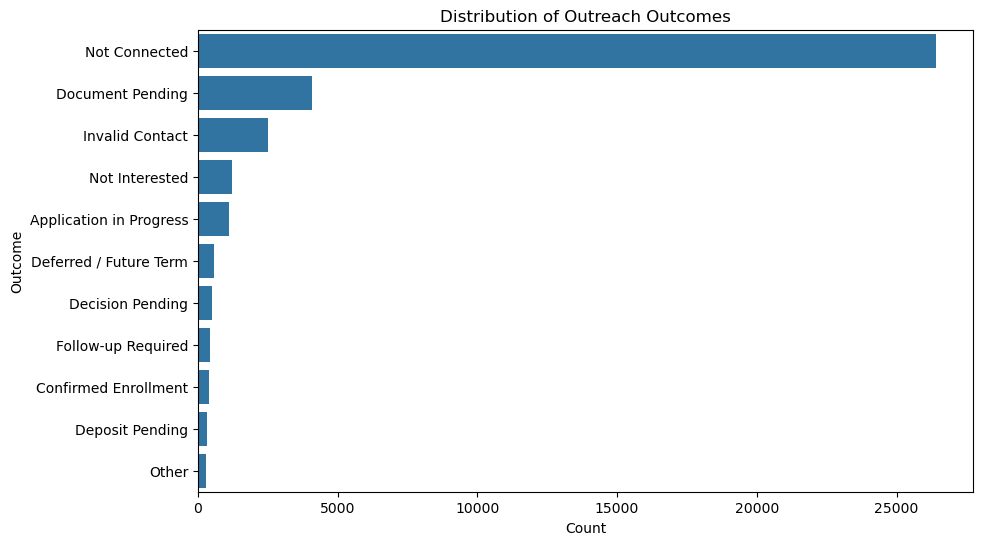

In [117]:
# Outcome Distribution
plt.figure(figsize=(10,6))
sns.countplot(data=outreach, y="Outcome_2", order=outreach["Outcome_2"].value_counts().index)
plt.title("Distribution of Outreach Outcomes")
plt.xlabel("Count")
plt.ylabel("Outcome")
plt.show()

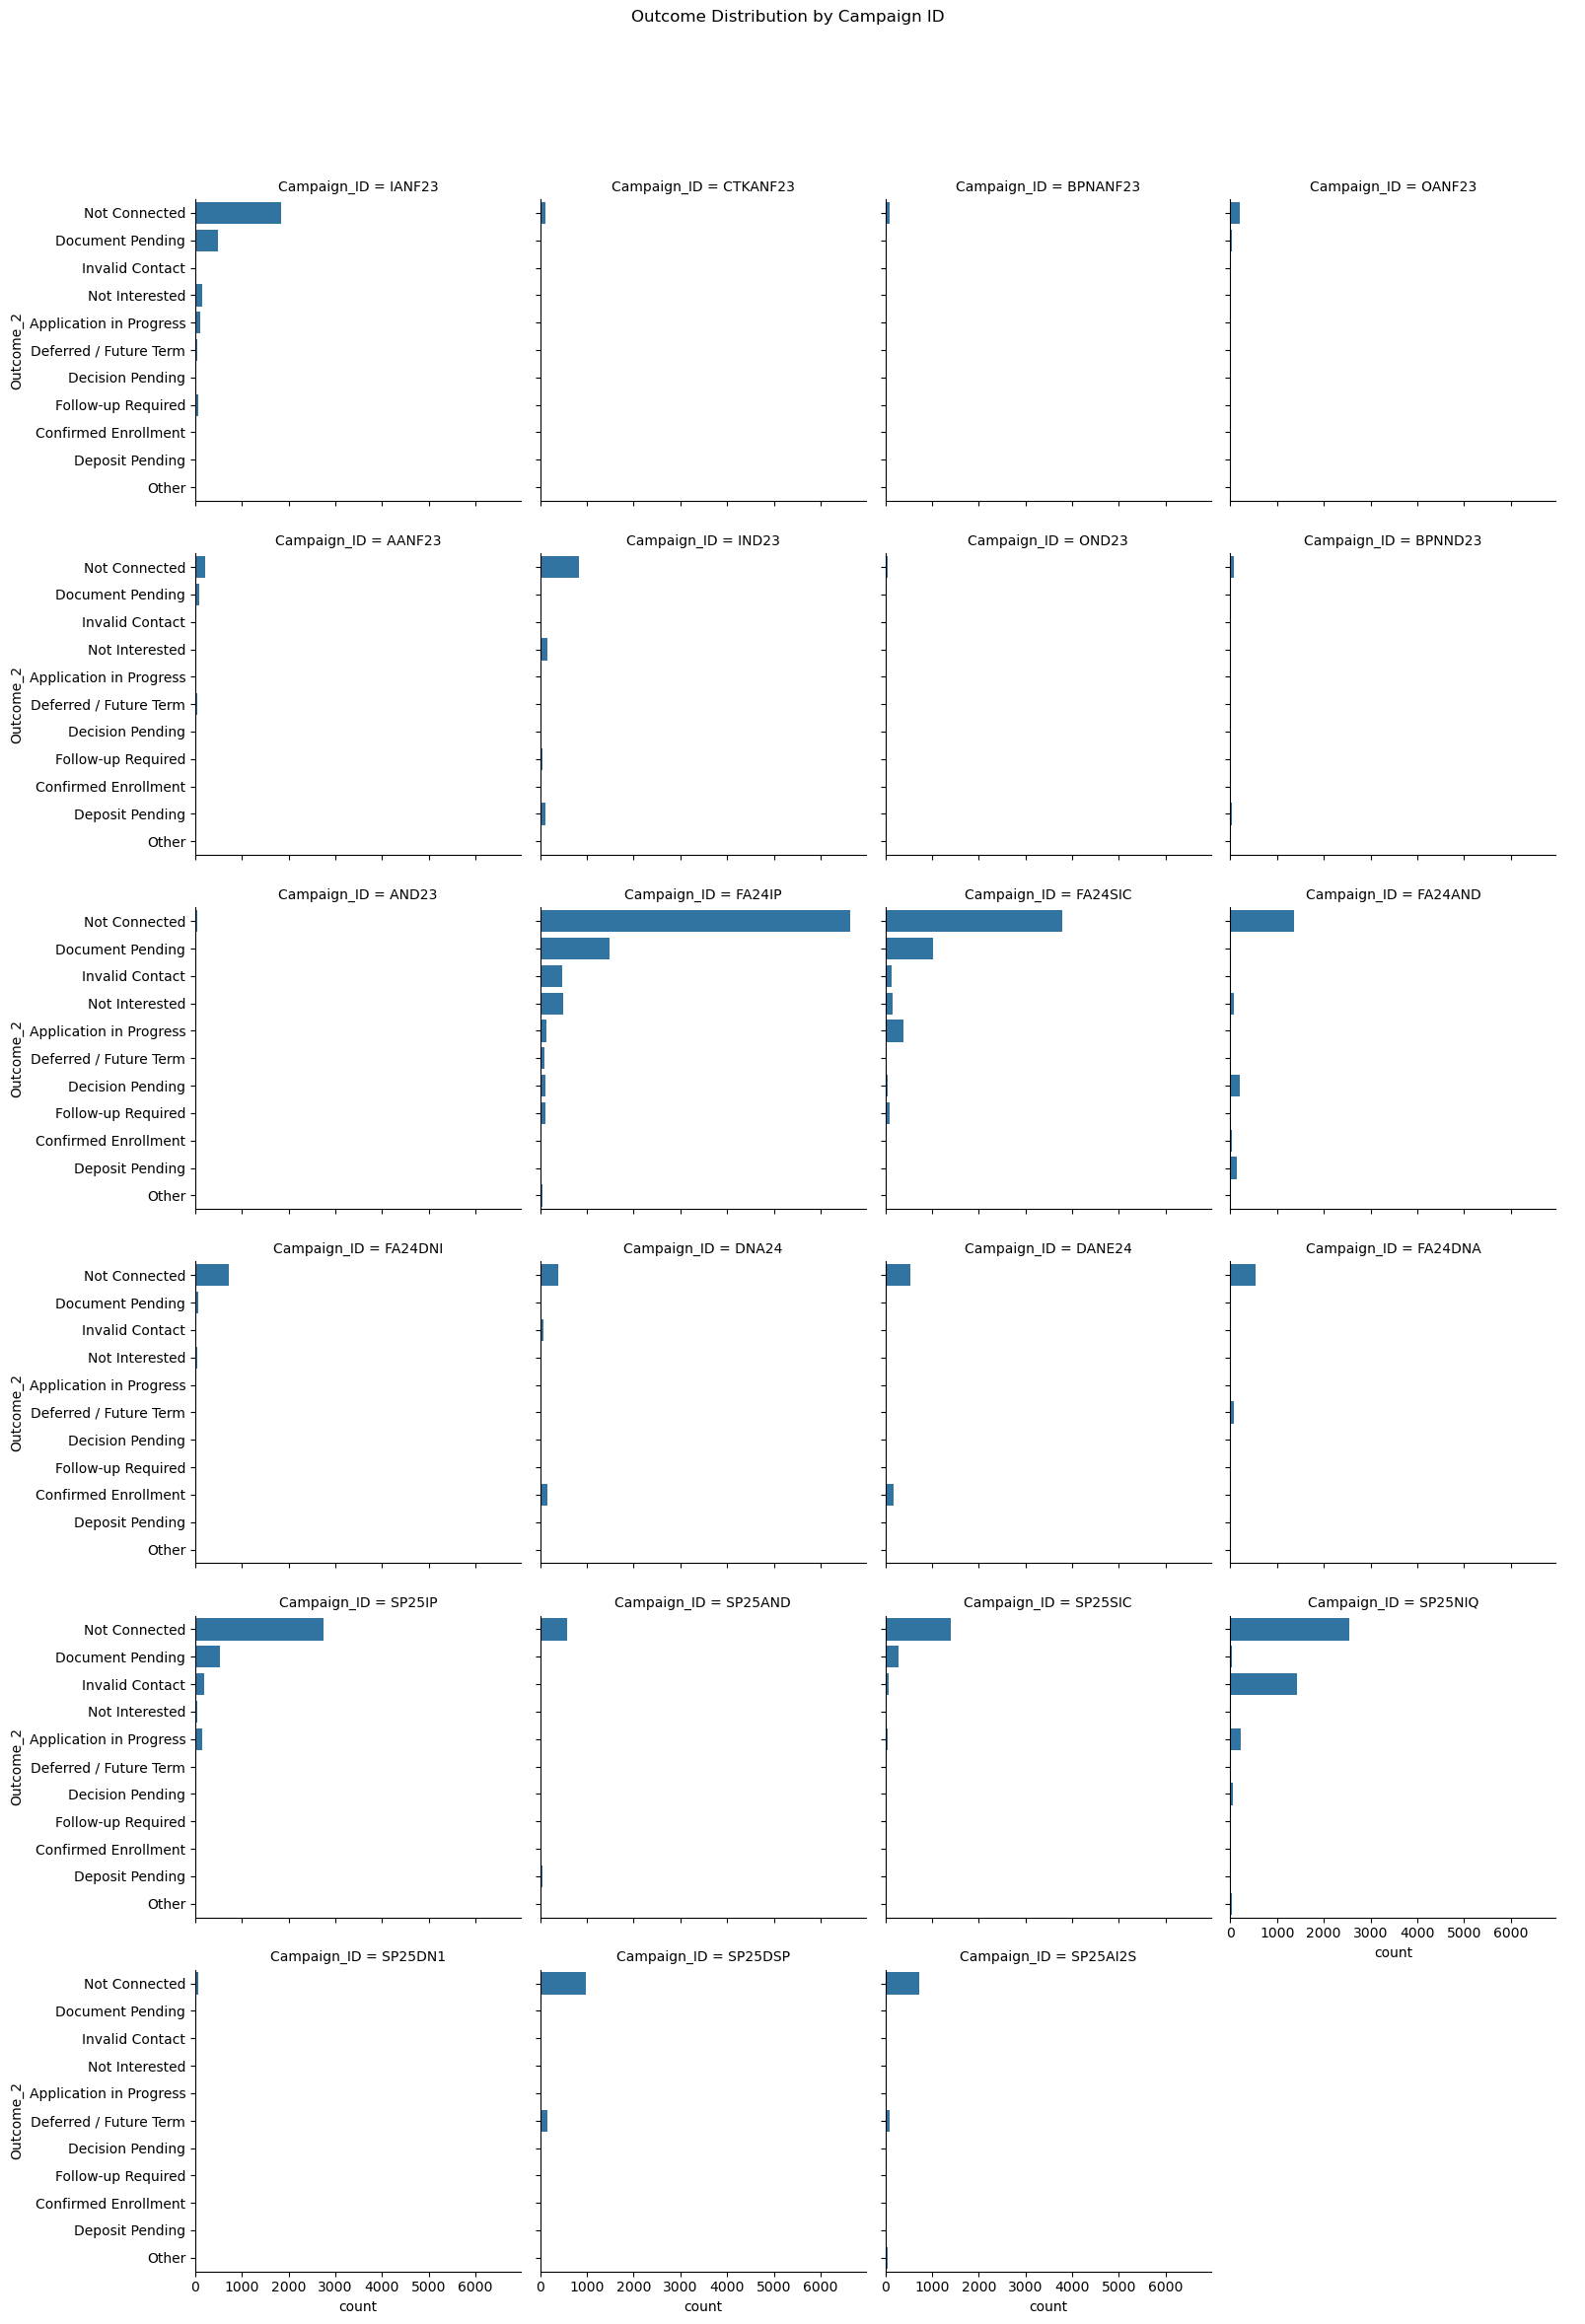

In [118]:
g = sns.catplot(
    data=outreach,
    y="Outcome_2",
    col="Campaign_ID",
    kind="count",
    col_wrap=4,   # number of plots per row
    order=outreach["Outcome_2"].value_counts().index,
    height=4,
    aspect=1
)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Outcome Distribution by Campaign ID")

plt.show()

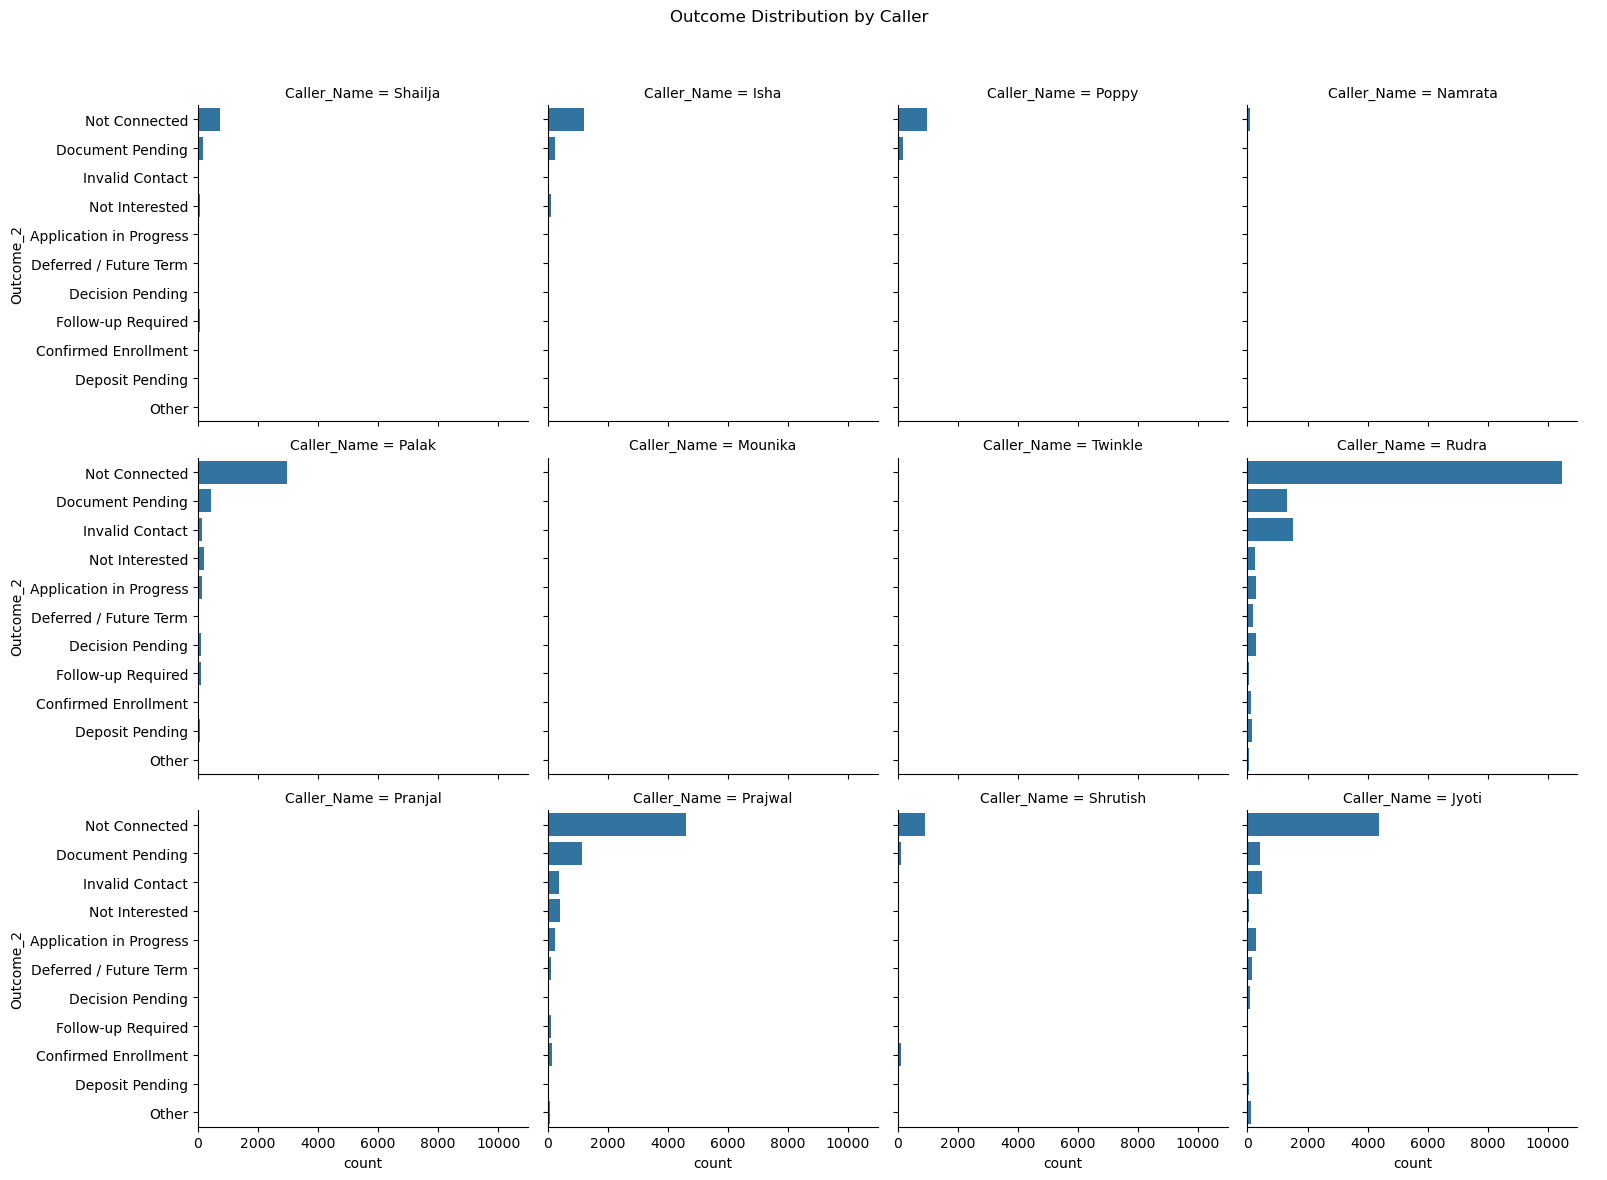

In [119]:
g = sns.catplot(
    data=outreach,
    y="Outcome_2",
    col="Caller_Name",
    kind="count",
    col_wrap=4,
    order=outreach["Outcome_2"].value_counts().index,
    height=4,
    aspect=1
)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Outcome Distribution by Caller")

plt.show()

In [120]:
funnel_map = {
    "Not Connected": "Leads",
    "Invalid Contact": "Leads",
    "Follow-up Required": "Connected",
    "Application in Progress": "Application",
    "Document Pending": "Application",
    "Deposit Pending": "Deposit",
    "Confirmed Enrollment": "Enrolled",
    "Deferred / Future Term": "Application",
    "Not Interested": "Connected"
}

outreach["funnel_stage"] = outreach["Outcome_2"].map(funnel_map)

In [121]:
funnel_counts = (
    outreach.groupby(["Campaign_ID", "funnel_stage"])
    .size()
    .unstack(fill_value=0)
)

funnel_counts

funnel_stage,Application,Connected,Deposit,Enrolled,Leads
Campaign_ID,,,,,
AANF23,143,35,0,0,222
AND23,6,13,14,6,36
BPNANF23,25,14,0,0,97
BPNND23,2,11,24,1,75
CTKANF23,4,4,0,0,102
DANE24,17,12,0,174,563
DNA24,17,8,0,151,451
FA24AND,19,97,134,40,1363
FA24DNA,71,9,0,0,546


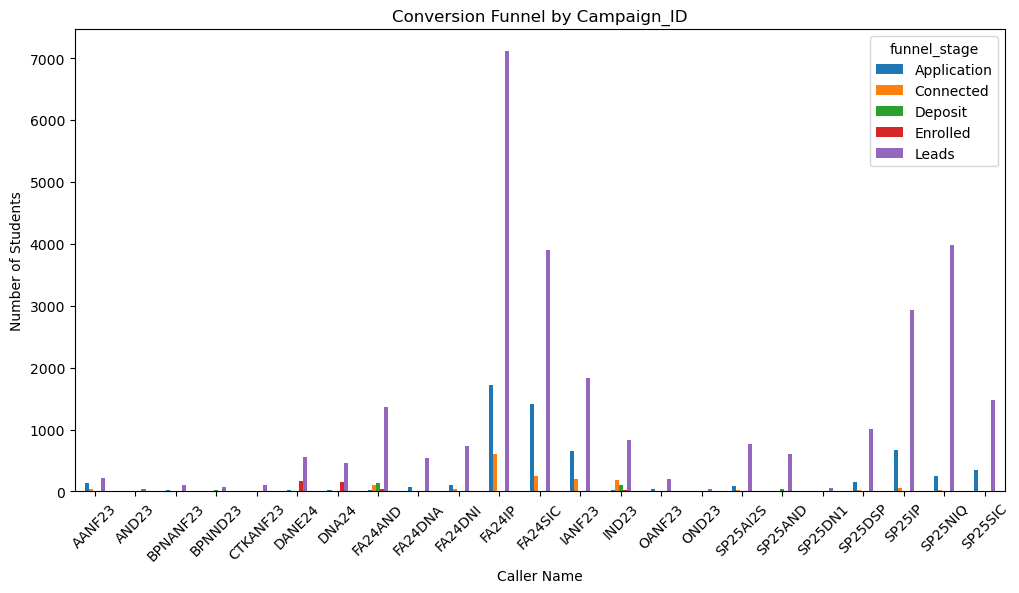

In [122]:
funnel_counts.plot(
    kind="bar",
    stacked=False,
    figsize=(12,6)
)

plt.title("Conversion Funnel by Campaign_ID")
plt.ylabel("Number of Students")
plt.xlabel("Caller Name")
plt.xticks(rotation=45)
plt.show()

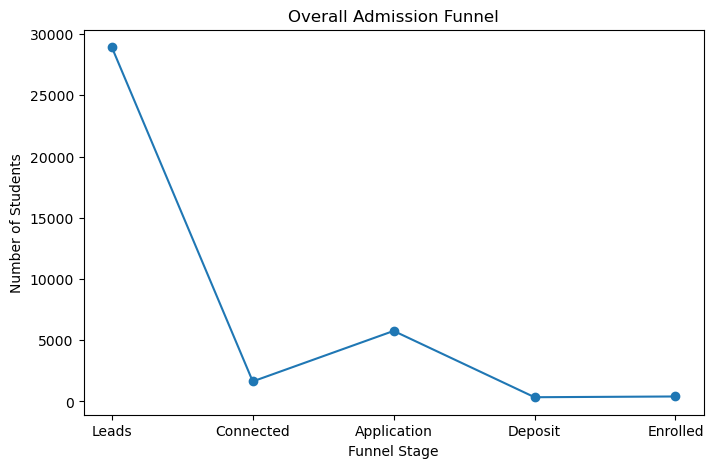

In [123]:
funnel_totals = outreach["funnel_stage"].value_counts()

stages = ["Leads","Connected","Application","Deposit","Enrolled"]
values = [funnel_totals.get(stage,0) for stage in stages]

plt.figure(figsize=(8,5))
plt.plot(stages, values, marker='o')
plt.title("Overall Admission Funnel")
plt.ylabel("Number of Students")
plt.xlabel("Funnel Stage")
plt.show()

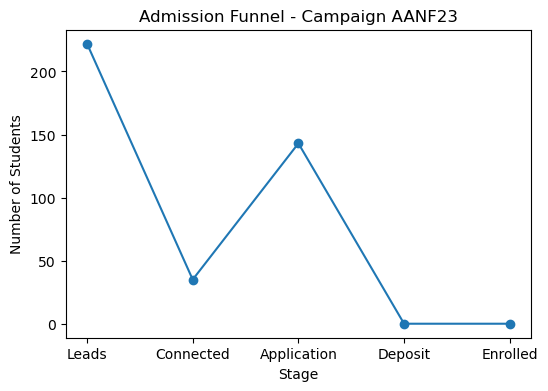

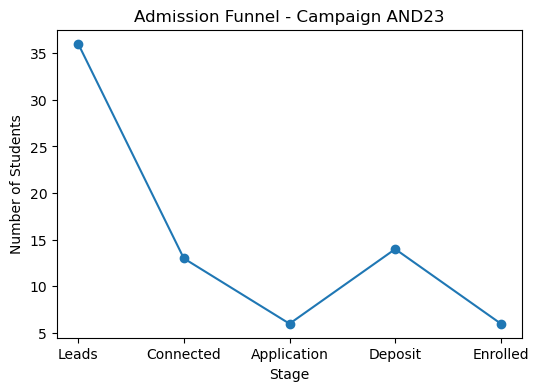

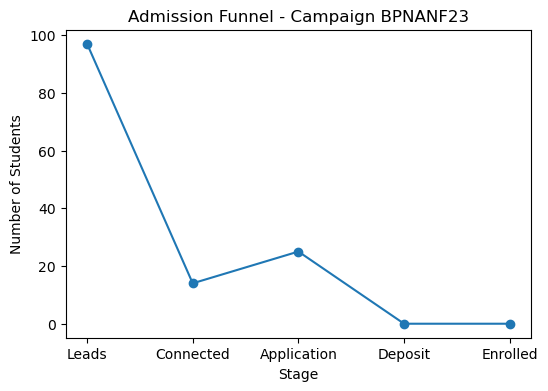

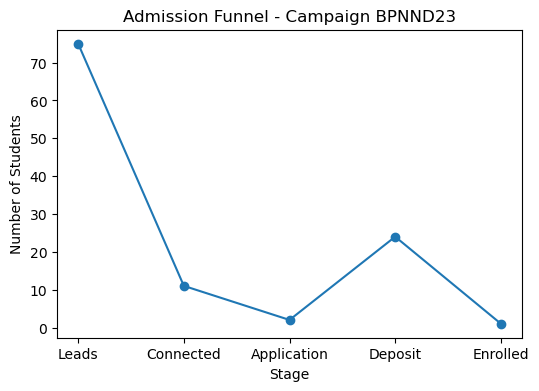

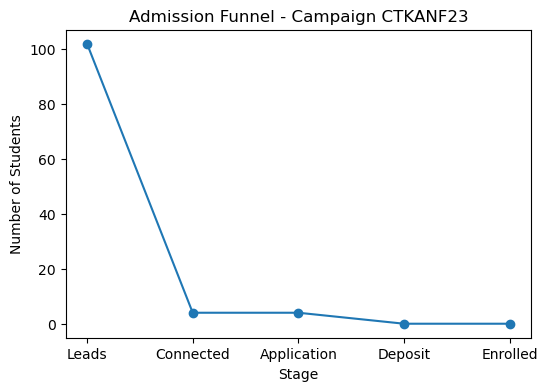

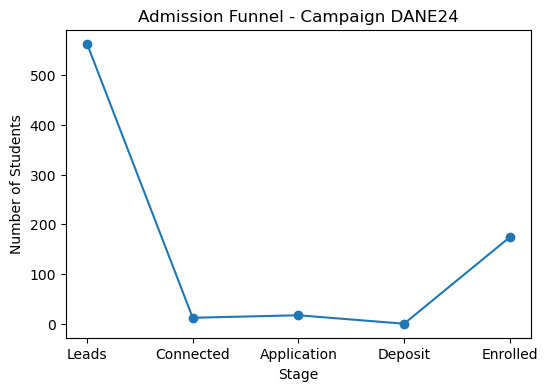

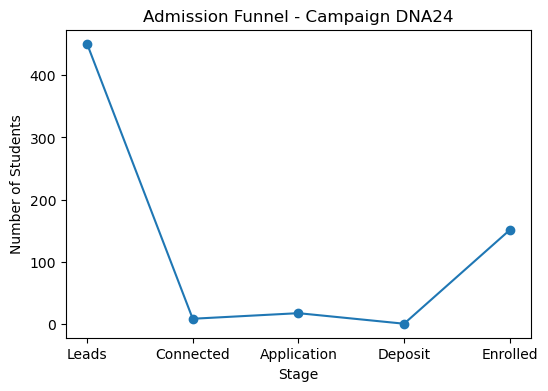

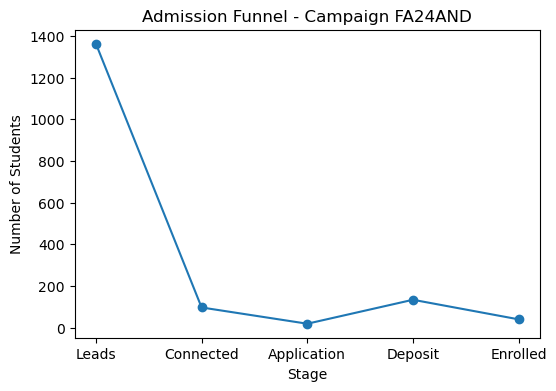

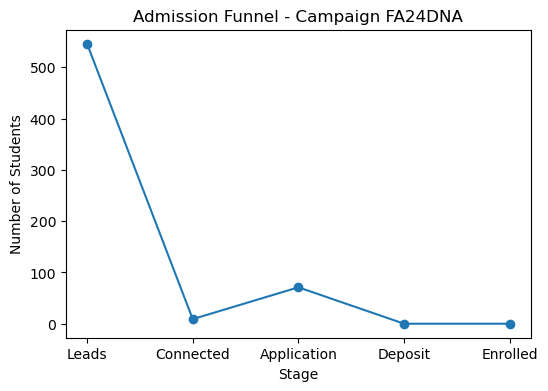

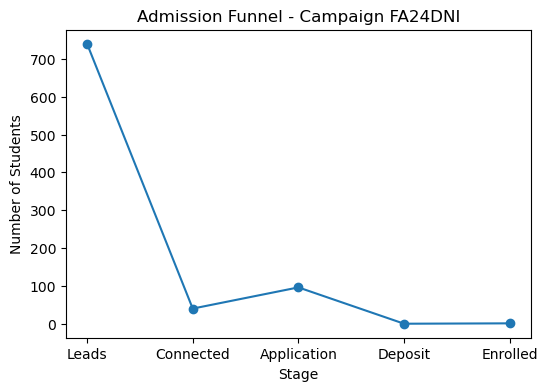

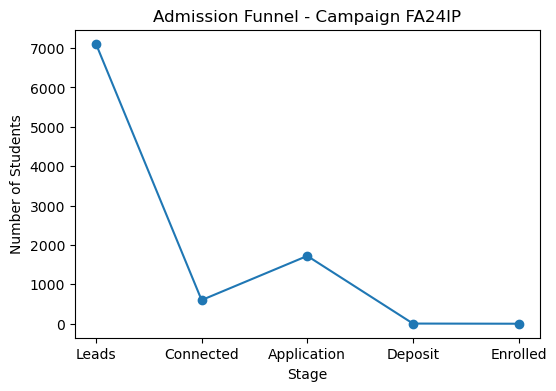

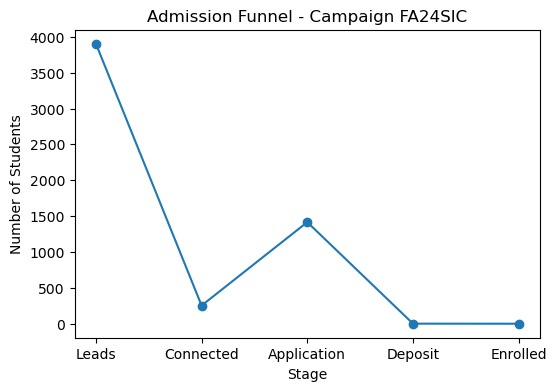

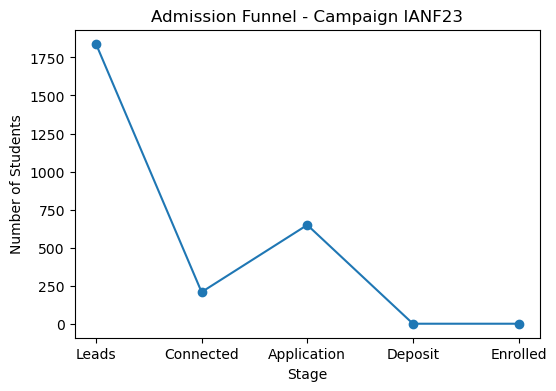

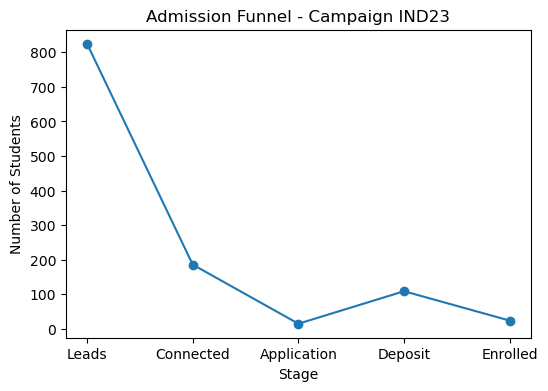

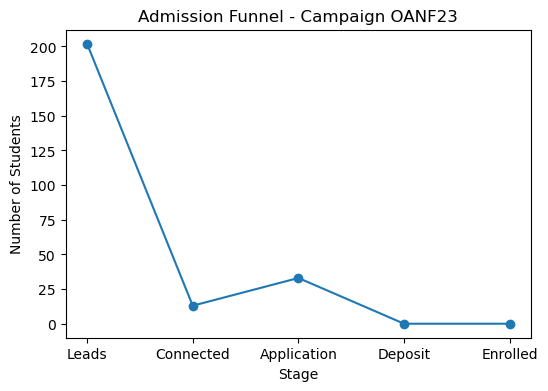

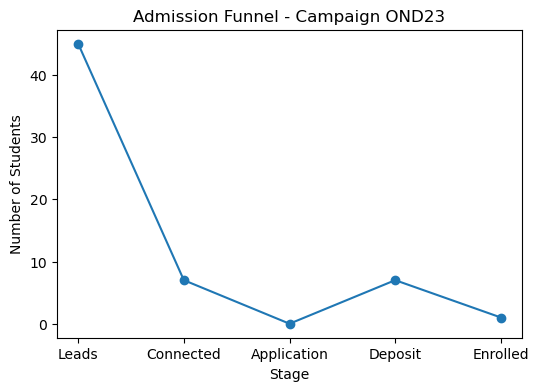

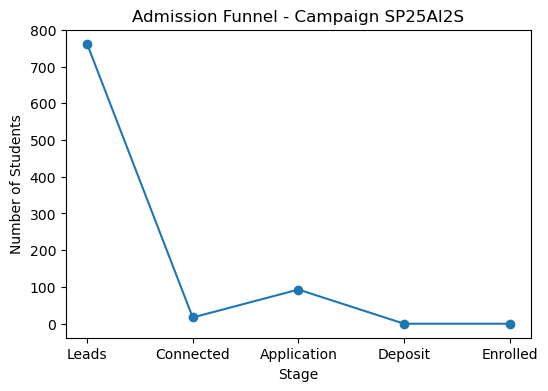

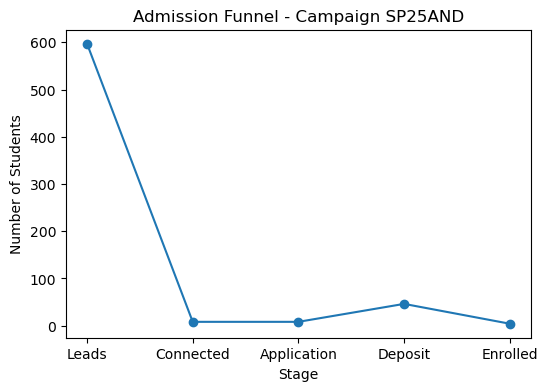

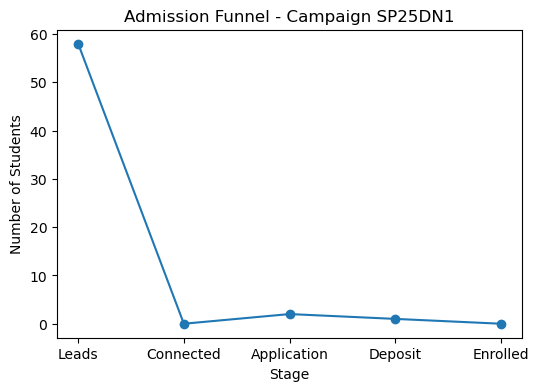

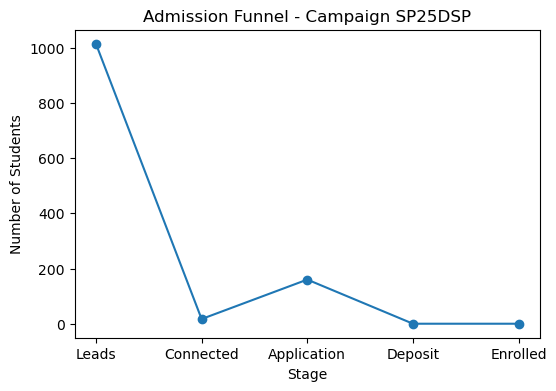

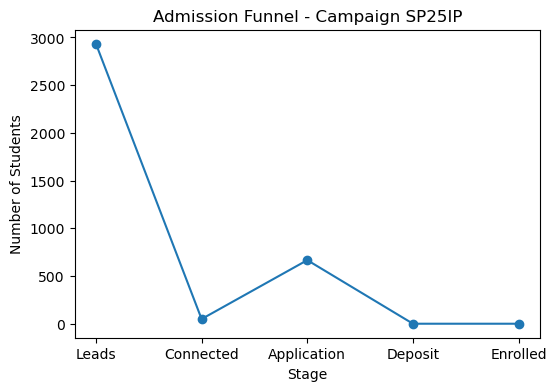

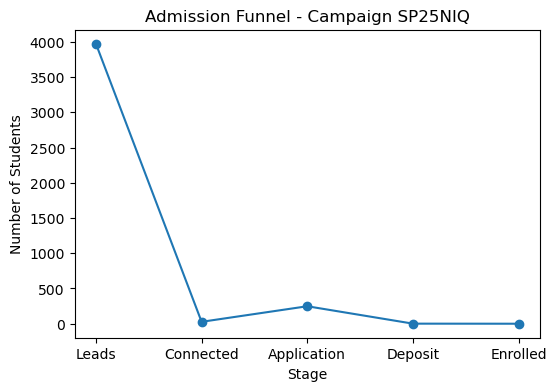

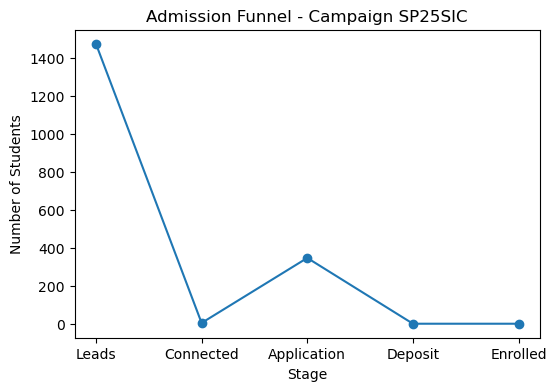

In [124]:
stages = ["Leads","Connected","Application","Deposit","Enrolled"]

for campaign in funnel_counts.index:
    
    values = [funnel_counts.loc[campaign].get(stage,0) for stage in stages]

    plt.figure(figsize=(6,4))
    plt.plot(stages, values, marker='o')
    plt.title(f"Admission Funnel - Campaign {campaign}")
    plt.ylabel("Number of Students")
    plt.xlabel("Stage")
    plt.show()

In [125]:
funnel_totals1 = outreach["Campaign_ID"].value_counts()
funnel_totals1

# Add total column
funnel_counts["Total"] = funnel_counts.index.map(funnel_totals1)

funnel_counts

funnel_stage,Application,Connected,Deposit,Enrolled,Leads,Total
Campaign_ID,,,,,,
AANF23,143,35,0,0,222,401
AND23,6,13,14,6,36,76
BPNANF23,25,14,0,0,97,136
BPNND23,2,11,24,1,75,114
CTKANF23,4,4,0,0,102,110
DANE24,17,12,0,174,563,805
DNA24,17,8,0,151,451,653
FA24AND,19,97,134,40,1363,1847
FA24DNA,71,9,0,0,546,646


In [126]:
funnel_counts["Enrollment Rate %"] = (
    (funnel_counts["Enrolled"] / funnel_counts["Total"]) * 100
)

funnel_counts["Application Rate %"] = (
    (funnel_counts["Application"] / funnel_counts["Total"]) * 100
)

funnel_counts.round(1)

funnel_stage,Application,Connected,Deposit,Enrolled,Leads,Total,Enrollment Rate %,Application Rate %
Campaign_ID,,,,,,,,
AANF23,143,35,0,0,222,401,0.0,35.7
AND23,6,13,14,6,36,76,7.9,7.9
BPNANF23,25,14,0,0,97,136,0.0,18.4
BPNND23,2,11,24,1,75,114,0.9,1.8
CTKANF23,4,4,0,0,102,110,0.0,3.6
DANE24,17,12,0,174,563,805,21.6,2.1
DNA24,17,8,0,151,451,653,23.1,2.6
FA24AND,19,97,134,40,1363,1847,2.2,1.0
FA24DNA,71,9,0,0,546,646,0.0,11.0


The top 3 campaigns having maximum enrollment are: DNA24, DANE24, AND23 \
The top 3 campaigns having maximum applications are: AANF23, FA24SIC, IANF23

In [127]:
total_calls = len(outreach)
confirmed = outreach[outreach["Outcome_2"] == "Confirmed Enrollment"]

conversion_rate = (len(confirmed) / total_calls) * 100

print("Admission Conversion Rate for overall data:", round(conversion_rate,2), "%")

Admission Conversion Rate for overall data: 1.07 %
